# Prediction-Driven Browser Recommendations Engine

This notebook demonstrates and analyzes the **recommendation pipeline**: it fuses the LSTM
next-session forecast with historical category affinity to produce a ranked list of
categories to engage next, with a transparent reason for every suggestion.

### Methodology
1. **LSTM forecast** — the next-session category predicted for each held-out session.
2. **Historical affinity** — how frequently each category appears in the user's browsing history.
3. **Ranked fusion** — the forecast always ranks first; remaining slots are filled by affinity.
4. **Transparency** — every recommendation carries a machine-readable reason.


## 1. Environment Setup

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def _find_project_root() -> Path:
    current = Path.cwd()

    while current != current.parent:
        if (current / "src").is_dir():
            return current

        current = current.parent

    raise RuntimeError("Could not locate the project root (missing src/ directory).")


PROJECT_ROOT = _find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
from src.recommendation.pipeline import RecommendationPipeline
from src.utils.mlflow_utils import get_tracking_uri, setup_mlflow

setup_mlflow()
print(f"MLflow Tracking URI: {get_tracking_uri()}")

/home/abishek/Projects/intelligent-browser-behaviour-analytics-platform/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-08-13 08:23:39,806 | INFO     | src.utils.mlflow_utils | MLflow tracking URI: file:///home/abishek/Projects/intelligent-browser-behaviour-analytics-platform/mlruns


MLflow Tracking URI: file:///home/abishek/Projects/intelligent-browser-behaviour-analytics-platform/mlruns


## 2. Generate Recommendations

In [3]:
pipeline = RecommendationPipeline()
recommendations = pipeline.run()

print(f"Recommendation rows: {len(recommendations):,}")
print(f"Target sessions covered: {recommendations['target_session_id'].nunique():,}")
recommendations.head(10)

2026-08-13 08:23:40,124 | INFO     | src.utils.mlflow_utils | MLflow tracking URI: file:///home/abishek/Projects/intelligent-browser-behaviour-analytics-platform/mlruns


2026-08-13 08:23:40,225 | INFO     | src.recommendation.pipeline | Recommendations generated | rows=415


Recommendation rows: 415
Target sessions covered: 83


,target_session_id,predicted_category,recommendation_rank,recommended_category,score,reason
0,747,Search/Reference,1,Search/Reference,1.653382,Matches the LSTM next-session forecast
1,747,Search/Reference,2,Social Media,0.107488,Frequently observed in your browsing history
2,747,Search/Reference,3,Learning/Education,0.072464,Frequently observed in your browsing history
3,747,Search/Reference,4,Productivity/Work,0.061594,Frequently observed in your browsing history
4,747,Search/Reference,5,Other,0.021739,Frequently observed in your browsing history
5,748,Search/Reference,1,Search/Reference,1.653382,Matches the LSTM next-session forecast
6,748,Search/Reference,2,Social Media,0.107488,Frequently observed in your browsing history
7,748,Search/Reference,3,Learning/Education,0.072464,Frequently observed in your browsing history
8,748,Search/Reference,4,Productivity/Work,0.061594,Frequently observed in your browsing history
9,748,Search/Reference,5,Other,0.021739,Frequently observed in your browsing history


## 3. Forecasted Category Distribution

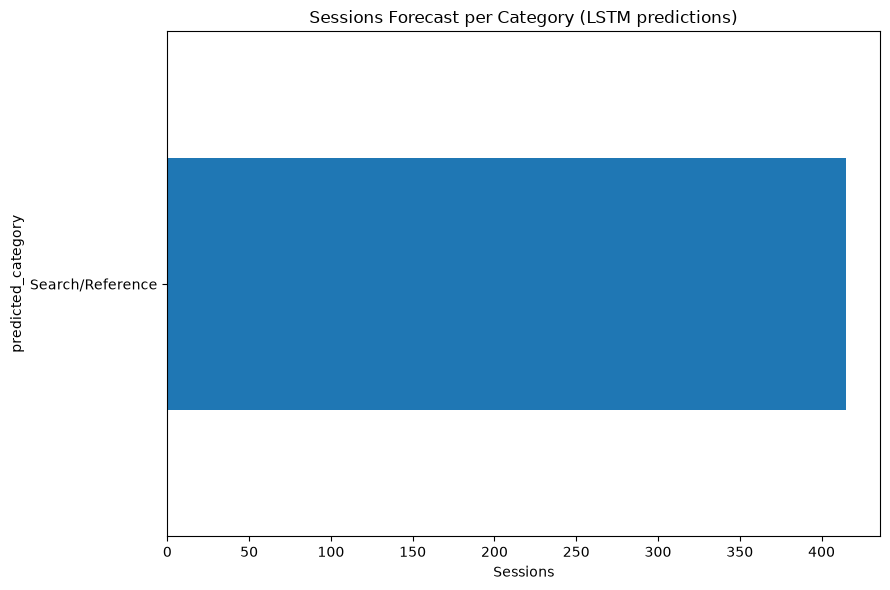

predicted_category
Search/Reference    415
Name: count, dtype: int64


In [4]:
forecast_counts = recommendations["predicted_category"].value_counts()
forecast_counts.plot(kind="barh", figsize=(9, 6), color="#1f77b4")
plt.title("Sessions Forecast per Category (LSTM predictions)")
plt.xlabel("Sessions")
plt.tight_layout()
plt.show()
print(forecast_counts)

## 4. Ranking & Recommendation Quality

In [5]:
rank_stats = recommendations.groupby("recommendation_rank")["score"].agg(["count", "mean"])
print("Recommendation rank distribution:")
print(rank_stats)

# How often is the forecast itself the top recommendation?
forecast_first = recommendations["reason"].str.contains("forecast", case=False).mean()
print(f"\nFraction of rows where the forecast category ranks first: {forecast_first:.2%}")

Recommendation rank distribution:
                     count      mean
recommendation_rank                 
1                       83  1.653382
2                       83  0.107488
3                       83  0.072464
4                       83  0.061594
5                       83  0.021739

Fraction of rows where the forecast category ranks first: 20.00%


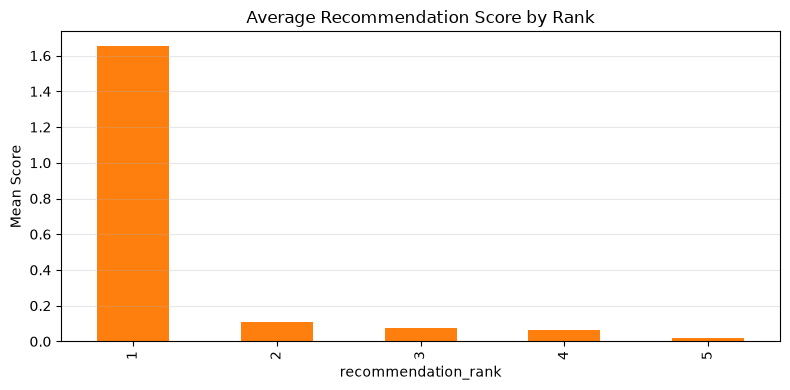

In [6]:
recommendations.groupby("recommendation_rank")["score"].mean().plot(
    kind="bar", figsize=(8, 4), color="#ff7f0e"
)
plt.title("Average Recommendation Score by Rank")
plt.ylabel("Mean Score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Sample Recommendation Cards

In [7]:
sample_session = recommendations["target_session_id"].iloc[0]
sample_recs = recommendations[recommendations["target_session_id"] == sample_session]

print(f"=== Recommendations for target session {sample_session} ===")
print(f"LSTM forecasted category: {sample_recs.iloc[0]['predicted_category']}\n")

for _, row in sample_recs.iterrows():
    print(f"  Rank #{row['recommendation_rank']}  {row['recommended_category']}  "
          f"(score {row['score']:.3f})")
    print(f"      reason: {row['reason']}")

=== Recommendations for target session 747 ===
LSTM forecasted category: Search/Reference

  Rank #1  Search/Reference  (score 1.653)
      reason: Matches the LSTM next-session forecast
  Rank #2  Social Media  (score 0.107)
      reason: Frequently observed in your browsing history
  Rank #3  Learning/Education  (score 0.072)
      reason: Frequently observed in your browsing history
  Rank #4  Productivity/Work  (score 0.062)
      reason: Frequently observed in your browsing history
  Rank #5  Other  (score 0.022)
      reason: Frequently observed in your browsing history


## 6. Coverage & Actionability Summary

In [8]:
summary = {
    "total_recommendations": len(recommendations),
    "target_sessions": recommendations["target_session_id"].nunique(),
    "top_k": recommendations["recommendation_rank"].max(),
    "categories_in_catalog": recommendations["recommended_category"].nunique(),
    "forecast_first_share": round(
        float(recommendations["reason"].str.contains("forecast", case=False).mean()), 3
    ),
}
pd.Series(summary, name="value").to_frame().style.format({"value": "{:,.3f}"})

,value
total_recommendations,415.000
target_sessions,83.000
top_k,5.000
categories_in_catalog,5.000
forecast_first_share,0.200
